# Appendix A1: Isometries of Euclidean Spaces

Source orientation: Pressley, *Elementary Differential Geometry*, Appendix A1, PDF pages 382-389.

This notebook is an original, standalone visualization-first pass over the assigned appendix span. The PDF was used only to orient the definitions, propositions, and route; no textbook prose, exercises, figures, screenshots, or page crops are reproduced.

## Chapter Goal

Build a computational picture of Euclidean isometries: every distance-preserving map of `R^n` has the affine form

`F(v) = P v + a`, where `P.T @ P = I`.

The notebook makes that statement inspectable. We will see what translation contributes, what an orthogonal matrix contributes, why determinant sign records orientation, how reflections behave as hyperplane mirrors, how rotations arise from two reflections in the plane, and how compositions multiply their linear parts.

## Translation Guide

| Book-side idea | Computational translation |
| --- | --- |
| Point or vector in `R^n` | A NumPy row vector; a finite constellation is an array of sample points. |
| Isometry | Pairwise distance matrix is unchanged after applying `F`. |
| Translation | `P = I`; every point receives the same displacement vector `a`. |
| Orthogonal matrix | `P.T @ P = I`; columns form an orthonormal frame and `det(P) = +/-1`. |
| Direct or opposite isometry | `det(P) = 1` preserves orientation; `det(P) = -1` reverses it. |
| Reflection in a hyperplane | `P = I - 2 N N.T` and `a = 2 d N`, with `N` unit and the fixed set `v dot N = d`. |
| Rotation in `R^2` | A direct orthogonal map fixing the origin; its columns are the rotated coordinate frame. |
| Composition | If `F(v)=Pv+a` and `G(v)=Qv+b`, then `G(F(v)) = QP v + Q a + b`. |
| `R^3` orientation | Cross products transform by `P v x P w = det(P) P(v x w)` for orthogonal `P`. |

## Route

1. Start with a finite point constellation and verify the affine normal form by a distance ledger.
2. Separate the two jobs in `F(v)=Pv+a`: translation moves every point equally, while `P` rotates or reflects the frame.
3. Inspect a reflection formula by drawing its mirror line, fixed points, and perpendicular connectors.
4. Compose reflections and track determinant signs to explain direct and opposite motions.
5. Move to `R^3` with an interactive frame view and cross-product orientation checks.
6. Finish with an applied lab that classifies several affine isometries from their matrix and translation data.


In [1]:
from pathlib import Path
import sys

START = Path.cwd()
candidate_roots = [START, *START.parents]
book_named = START / "Elementary-Differential-Geometry-Andrew-Pressley"
if book_named.exists():
    candidate_roots.append(book_named)

for candidate in candidate_roots:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Pressley book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

UNIT = "appendix-a1"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
UNIT_ARTIFACT_ROOT = ARTIFACT_ROOT / UNIT
FIG_DIR = UNIT_ARTIFACT_ROOT / "figures"
CHECK_DIR = UNIT_ARTIFACT_ROOT / "checks"
TABLE_DIR = UNIT_ARTIFACT_ROOT / "tables"
INTERACTIVE_DIR = UNIT_ARTIFACT_ROOT / "interactive"
for folder in [FIG_DIR, CHECK_DIR, TABLE_DIR, INTERACTIVE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

from utils.artifacts import assert_artifact, display_artifact

NOTEBOOK_PATH = BOOK_ROOT / "appendix-a1-isometries-of-euclidean-spaces" / "a1-isometries-of-euclidean-spaces.ipynb"
BOOK_ROOT.relative_to(BOOK_ROOT.parent)


WindowsPath('Elementary-Differential-Geometry-Andrew-Pressley')

In [2]:
import json

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, FancyArrowPatch
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})


def rotation_matrix(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]], dtype=float)


def rodrigues(axis, theta):
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)
    x, y, z = axis
    K = np.array([[0, -z, y], [z, 0, -x], [-y, x, 0]], dtype=float)
    I = np.eye(3)
    return I + np.sin(theta) * K + (1 - np.cos(theta)) * (K @ K)


def reflection_matrix_from_normal(normal):
    normal = np.asarray(normal, dtype=float)
    normal = normal / np.linalg.norm(normal)
    return np.eye(len(normal)) - 2 * np.outer(normal, normal)


def line_reflection_matrix(phi):
    u = np.array([np.cos(phi), np.sin(phi)])
    return 2 * np.outer(u, u) - np.eye(2)


def apply_affine(P, a, points):
    points = np.asarray(points, dtype=float)
    a = np.asarray(a, dtype=float)
    return points @ P.T + a


def pairwise_distances(points):
    points = np.asarray(points, dtype=float)
    delta = points[:, None, :] - points[None, :, :]
    return np.linalg.norm(delta, axis=-1)


def max_distance_error(points, image):
    return float(np.max(np.abs(pairwise_distances(points) - pairwise_distances(image))))


def orthogonal_residual(P):
    P = np.asarray(P, dtype=float)
    return float(np.linalg.norm(P.T @ P - np.eye(P.shape[0]), ord=np.inf))


def signed_area2(triangle):
    p = np.asarray(triangle, dtype=float)
    return float(np.linalg.det(np.vstack([p[1] - p[0], p[2] - p[0]])))


def draw_vector(ax, start, end, *, color, label=None, lw=1.8, mutation_scale=12, alpha=1.0):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        linewidth=lw,
        color=color,
        alpha=alpha,
    )
    ax.add_patch(arrow)
    if label:
        midpoint = (np.asarray(start) + np.asarray(end)) / 2
        ax.text(midpoint[0], midpoint[1], label, color=color, fontsize=9)
    return arrow


def set_equal_axis(ax, xlim=(-1.4, 2.4), ylim=(-1.2, 2.0)):
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.axhline(0, color="0.82", lw=0.8)
    ax.axvline(0, color="0.82", lw=0.8)
    ax.grid(True, color="0.9", linewidth=0.7)


def write_check(filename, data):
    path = CHECK_DIR / filename
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    return path


def save_figure(fig, filename):
    path = FIG_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    return path


base_points = np.array([
    [-0.25, -0.15],
    [0.95, -0.05],
    [1.22, 0.72],
    [0.18, 1.03],
])
base_triangle = base_points[:3]


## Chapter-Specific Visual Storyboard

The appendix is short, but it carries a large structural claim: distance preservation forces an affine orthogonal formula. The visuals below are not examples after the fact; each one exposes a part of that formula.

| Visual | Concept | Library route | What to inspect | Check |
| --- | --- | --- | --- | --- |
| Affine isometry distance ledger | `F(v)=Pv+a` with `P` orthogonal | NumPy + Matplotlib | Distances are unchanged even though the whole constellation moves. | Pairwise distance residual and `P.T @ P - I`. |
| Translation vector field | Translation as direct isometry | NumPy + Matplotlib | All arrows are parallel and equal. | Uniform displacement and distance residual. |
| Hyperplane reflection | Formula `v - 2(v dot N - d)N` | NumPy + Matplotlib | Points move perpendicularly to the mirror, while mirror points stay fixed. | Self-inverse, fixed set, determinant sign. |
| Rotation and composition | Two line reflections produce a rotation; determinant signs multiply. | NumPy + Matplotlib | The intermediate reflection and final rotated vector. | Matrix residual against the rotation matrix. |
| `R^3` orientation scene | Axis rotation, plane reflection, and cross-product sign | NumPy + Plotly | Direct frames keep handedness; opposite frames reverse it. | Cross-product identity and determinant sign. |
| Applied lab | Classify affine isometries from data | NumPy + pandas | Fixed-set dimension, determinant sign, inverse check. | CSV and JSON residuals. |


In [3]:
source_span = {
    "book": "Andrew Pressley, Elementary Differential Geometry, Second Edition",
    "unit": "appendix-a1",
    "title": "Isometries of Euclidean spaces",
    "pdf_pages": "382-389",
    "printed_label": "Appendix 1",
    "source_use": "orientation only; no prose, figures, exercises, screenshots, or page crops copied",
}

visual_storyboard = {
    "chapter_goal": "Turn Euclidean distance preservation into affine orthogonal data and inspect translations, reflections, rotations, orientation, and composition.",
    "source_span_read": source_span,
    "concept_inventory": [
        "isometry as pairwise-distance preservation",
        "affine normal form F(v)=Pv+a",
        "orthogonal columns and determinant sign",
        "translations as direct isometries",
        "reflections in hyperplanes and their fixed sets",
        "rotation in R2 and rotation axis in R3",
        "composition law for affine orthogonal maps",
        "orientation behavior through signed area and cross product",
    ],
    "library_routing_table": [
        {"concept": "finite Euclidean distance ledger", "representation": "labeled 2D constellation plus residual heatmap", "library": "NumPy + Matplotlib", "why": "durable static diagram and exact numeric distance matrix"},
        {"concept": "reflection formula", "representation": "mirror line, normal direction, fixed points, perpendicular connectors", "library": "NumPy + Matplotlib", "why": "the construction is planar and metric"},
        {"concept": "R3 axis and handedness", "representation": "interactive 3D frame scene", "library": "Plotly", "why": "rotating the scene makes axis and orientation more inspectable than a flat projection"},
        {"concept": "symbolic orthogonality identities", "representation": "exact matrix identities", "library": "SymPy", "why": "exact signs and trigonometric identities should not depend on floating-point samples"},
        {"concept": "classification lab", "representation": "small table of affine cases", "library": "pandas + NumPy", "why": "readable ledger of determinant, fixed-set, and residual data"},
    ],
    "visual_sequence": [
        {"artifact": "figures/isometry-appendix-a1.png", "inspection_target": "unchanged distance matrix under a direct affine isometry", "validation": "distance residual and orthogonal residual"},
        {"artifact": "figures/translation-appendix-a1.png", "inspection_target": "constant displacement vectors", "validation": "uniform displacement residual"},
        {"artifact": "figures/reflection-appendix-a1.png", "inspection_target": "mirror fixed set and perpendicular point pairs", "validation": "self-inverse residual and determinant -1"},
        {"artifact": "figures/rotation-appendix-a1.png", "inspection_target": "rotated orthonormal frame and signed area preservation", "validation": "determinant +1 and distance residual"},
        {"artifact": "figures/composition-appendix-a1.png", "inspection_target": "two reflections compose to a rotation and signs multiply", "validation": "matrix residual and determinant product table"},
        {"artifact": "interactive/r3-orientation-cross-product.html", "inspection_target": "axis rotation versus plane reflection in R3", "validation": "cross-product orientation identity"},
    ],
    "computational_checks": [
        "orthogonal residuals for every matrix used",
        "pairwise distance preservation on sample constellations",
        "reflection self-inverse and fixed-hyperplane tests",
        "composition formula QP and Qa+b",
        "symbolic rotation/reflection determinant identities",
        "artifact existence and nonzero file size",
    ],
    "proof_visualization_strategy": "Use finite constellations, fixed-set diagrams, determinant ledgers, and exact symbolic identities as proof scaffolds for the appendix propositions.",
    "acceptance_criteria": [
        "notebook contains no generic unit visual builder call",
        "all artifacts live under artifacts/appendix-a1",
        "final_sanity records core residuals below tolerance",
        "the applied lab classifies both direct and opposite examples",
    ],
}

source_path = write_check("source-span.json", source_span)
storyboard_path = write_check("visual-storyboard.json", visual_storyboard)
assert_artifact(source_path, min_bytes=128)
assert_artifact(storyboard_path, min_bytes=512)
visual_storyboard["visual_sequence"]


[{'artifact': 'figures/isometry-appendix-a1.png',
  'inspection_target': 'unchanged distance matrix under a direct affine isometry',
  'validation': 'distance residual and orthogonal residual'},
 {'artifact': 'figures/translation-appendix-a1.png',
  'inspection_target': 'constant displacement vectors',
  'validation': 'uniform displacement residual'},
 {'artifact': 'figures/reflection-appendix-a1.png',
  'inspection_target': 'mirror fixed set and perpendicular point pairs',
  'validation': 'self-inverse residual and determinant -1'},
 {'artifact': 'figures/rotation-appendix-a1.png',
  'inspection_target': 'rotated orthonormal frame and signed area preservation',
  'validation': 'determinant +1 and distance residual'},
 {'artifact': 'figures/composition-appendix-a1.png',
  'inspection_target': 'two reflections compose to a rotation and signs multiply',
  'validation': 'matrix residual and determinant product table'},
 {'artifact': 'interactive/r3-orientation-cross-product.html',
  'insp

## 1. Affine Normal Form As A Distance Ledger

The theorem behind the appendix says that a Euclidean isometry is not an arbitrary nonlinear distance trick. It is an orthogonal linear frame change followed by a translation. On a finite constellation, the most direct computational test is the whole pairwise distance matrix.

In the figure, the blue polygon is the original data. The red polygon is the image under `F(v)=Pv+a`, with `P` a rotation matrix. The right panel is the absolute error between the original and transformed distance matrices; a correct isometry leaves it numerically dark.


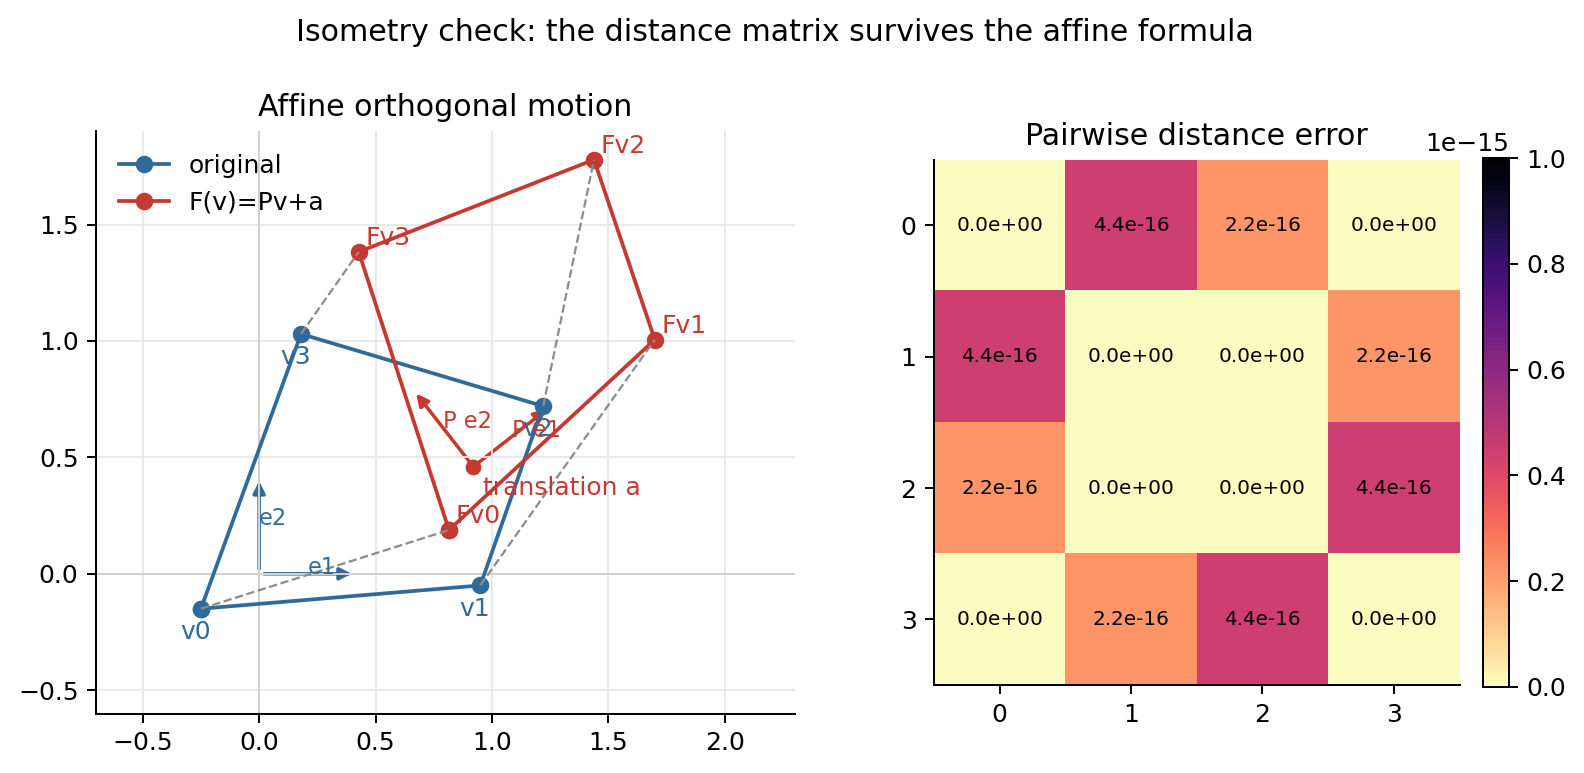

{'orthogonal_residual': 1.3480784663045066e-16,
 'determinant': 1.0,
 'max_pairwise_distance_error': 4.440892098500626e-16,
 'translation_vector': [0.92, 0.46],
 'point_count': 4}

In [4]:
theta = np.deg2rad(38)
P_direct = rotation_matrix(theta)
a_direct = np.array([0.92, 0.46])
image_direct = apply_affine(P_direct, a_direct, base_points)
D0 = pairwise_distances(base_points)
D1 = pairwise_distances(image_direct)
distance_error = np.abs(D0 - D1)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2), gridspec_kw={"width_ratios": [1.25, 1]})
ax = axes[0]
set_equal_axis(ax, (-0.7, 2.3), (-0.6, 1.9))
closed = np.r_[base_points, base_points[:1]]
closed_img = np.r_[image_direct, image_direct[:1]]
ax.plot(closed[:, 0], closed[:, 1], "o-", color="#2F6B9A", label="original")
ax.plot(closed_img[:, 0], closed_img[:, 1], "o-", color="#C43A31", label="F(v)=Pv+a")
for p, q in zip(base_points, image_direct):
    ax.plot([p[0], q[0]], [p[1], q[1]], color="0.55", linestyle="--", lw=0.9)
for label, p in zip(["v0", "v1", "v2", "v3"], base_points):
    ax.text(p[0] - 0.09, p[1] - 0.13, label, color="#2F6B9A")
for label, p in zip(["Fv0", "Fv1", "Fv2", "Fv3"], image_direct):
    ax.text(p[0] + 0.03, p[1] + 0.03, label, color="#C43A31")
origin = np.array([0.0, 0.0])
for basis, color, label in [(np.eye(2)[0], "#2F6B9A", "e1"), (np.eye(2)[1], "#2F6B9A", "e2")]:
    draw_vector(ax, origin, 0.42 * basis, color=color, label=label, lw=1.4, mutation_scale=10)
for basis, label in [(P_direct[:, 0], "P e1"), (P_direct[:, 1], "P e2")]:
    draw_vector(ax, a_direct, a_direct + 0.42 * basis, color="#C43A31", label=label, lw=1.4, mutation_scale=10)
ax.scatter([a_direct[0]], [a_direct[1]], color="#C43A31", s=28)
ax.text(a_direct[0] + 0.04, a_direct[1] - 0.12, "translation a", color="#C43A31")
ax.legend(loc="upper left", frameon=False)
ax.set_title("Affine orthogonal motion")

im = axes[1].imshow(distance_error, cmap="magma_r", vmin=0, vmax=max(1e-15, distance_error.max()))
axes[1].set_title("Pairwise distance error")
axes[1].set_xticks(range(len(base_points)))
axes[1].set_yticks(range(len(base_points)))
for i in range(len(base_points)):
    for j in range(len(base_points)):
        axes[1].text(j, i, f"{distance_error[i, j]:.1e}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
fig.suptitle("Isometry check: the distance matrix survives the affine formula", y=1.03)

isometry_fig = save_figure(fig, "isometry-appendix-a1.png")
isometry_checks = {
    "orthogonal_residual": orthogonal_residual(P_direct),
    "determinant": float(np.linalg.det(P_direct)),
    "max_pairwise_distance_error": float(distance_error.max()),
    "translation_vector": a_direct.tolist(),
    "point_count": int(len(base_points)),
}
isometry_check_path = write_check("orthogonal-affine-checks.json", isometry_checks)
assert isometry_checks["max_pairwise_distance_error"] < 1e-12
assert isometry_checks["orthogonal_residual"] < 1e-12
display_artifact(isometry_fig, width=920)
isometry_checks


## 2. Translation: The Linear Part Is Silent

A translation is the special case `P=I`. It is direct because its linear part has determinant `1`, but all visible motion comes from `a`. The diagram below is intentionally a vector field: if one arrow differs from the others, it is not a pure translation.


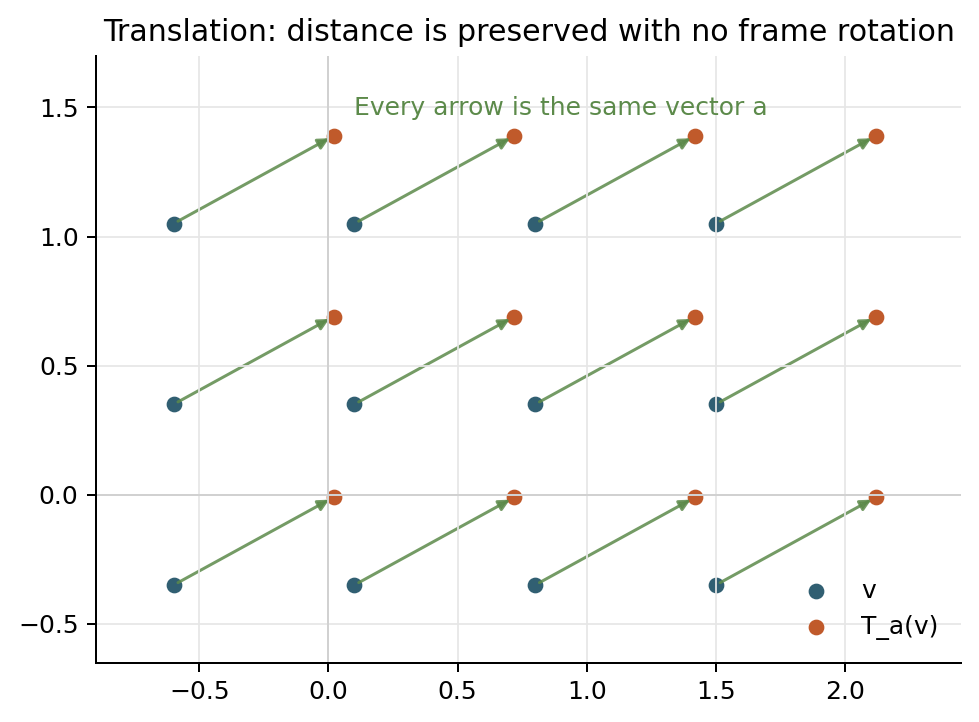

{'determinant': 1.0,
 'uniform_displacement_residual': 1.2412670766236366e-16,
 'max_pairwise_distance_error': 4.440892098500626e-16,
 'translation_vector': [0.62, 0.34]}

In [5]:
a_translation = np.array([0.62, 0.34])
translation_grid = np.array([[x, y] for x in [-0.6, 0.1, 0.8, 1.5] for y in [-0.35, 0.35, 1.05]])
translation_image = apply_affine(np.eye(2), a_translation, translation_grid)
translation_displacements = translation_image - translation_grid
uniform_residual = float(np.max(np.linalg.norm(translation_displacements - a_translation, axis=1)))

fig, ax = plt.subplots(figsize=(6.2, 4.4))
set_equal_axis(ax, (-0.9, 2.45), (-0.65, 1.7))
ax.scatter(translation_grid[:, 0], translation_grid[:, 1], color="#315F72", s=28, label="v")
ax.scatter(translation_image[:, 0], translation_image[:, 1], color="#C05A2B", s=28, label="T_a(v)")
for p, q in zip(translation_grid, translation_image):
    draw_vector(ax, p, q, color="#5C8A4A", lw=1.2, mutation_scale=9, alpha=0.85)
ax.text(0.1, 1.47, "Every arrow is the same vector a", color="#5C8A4A")
ax.legend(loc="lower right", frameon=False)
ax.set_title("Translation: distance is preserved with no frame rotation")

translation_fig = save_figure(fig, "translation-appendix-a1.png")
translation_checks = {
    "determinant": 1.0,
    "uniform_displacement_residual": uniform_residual,
    "max_pairwise_distance_error": max_distance_error(translation_grid, translation_image),
    "translation_vector": a_translation.tolist(),
}
translation_check_path = write_check("translation-checks.json", translation_checks)
assert translation_checks["uniform_displacement_residual"] < 1e-12
assert translation_checks["max_pairwise_distance_error"] < 1e-12
display_artifact(translation_fig, width=760)
translation_checks


## 3. Reflection In A Hyperplane

A reflection is the clearest opposite isometry because the fixed set is visible. Choose a unit normal `N` and a scalar `d`. The mirror is the line `v dot N = d` in the plane, and the formula

`R_H(v) = v - 2 (v dot N - d) N`

subtracts twice the signed normal offset. Points on the line have zero offset and do not move; all other points cross the line along a perpendicular segment.


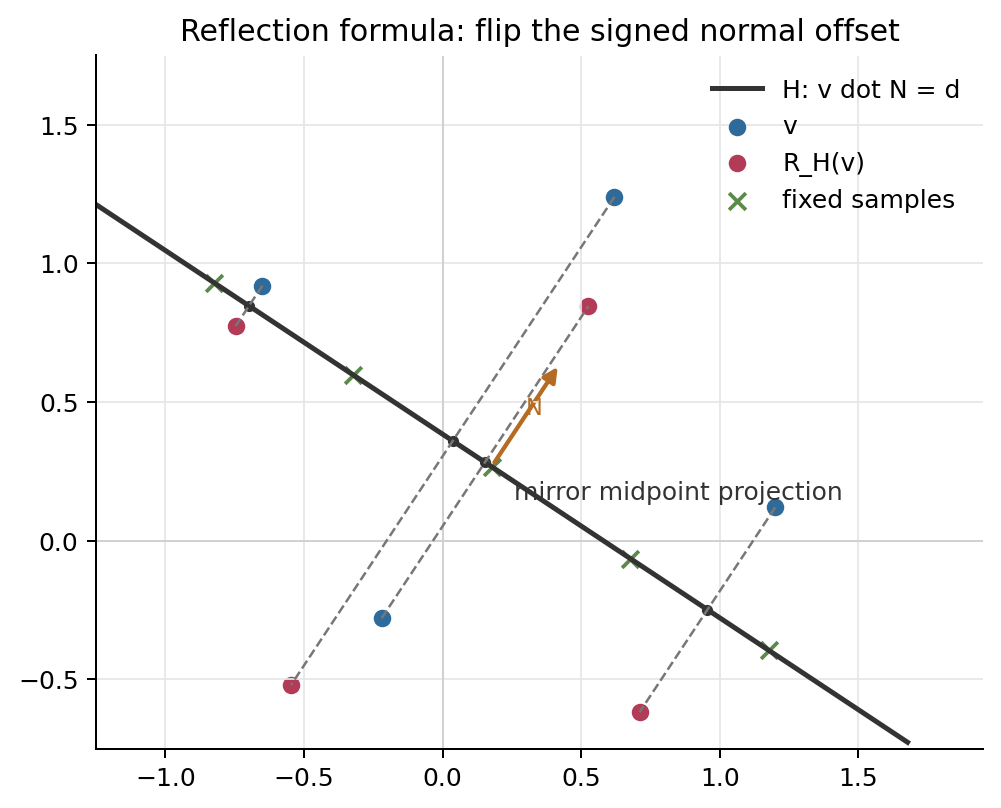

{'normal': [0.552380364401192, 0.8335921862781622],
 'd': 0.32,
 'orthogonal_residual': 3.161147499261532e-16,
 'determinant': -0.9999999999999998,
 'self_inverse_residual': 4.002966042486721e-16,
 'fixed_set_residual': 2.220446049250313e-16,
 'mirror_equation_residual': 1.1102230246251565e-16,
 'max_pairwise_distance_error': 4.440892098500626e-16}

In [6]:
N = np.array([0.55, 0.83])
N = N / np.linalg.norm(N)
d = 0.32
P_reflect = reflection_matrix_from_normal(N)
a_reflect = 2 * d * N
reflection_points = np.array([
    [-0.65, 0.92],
    [-0.22, -0.28],
    [0.62, 1.24],
    [1.20, 0.12],
])
reflection_image = apply_affine(P_reflect, a_reflect, reflection_points)
reflection_back = apply_affine(P_reflect, a_reflect, reflection_image)
T = np.array([-N[1], N[0]])
line_center = d * N
line_t = np.linspace(-1.8, 1.8, 2)
mirror_line = line_center + line_t[:, None] * T
fixed_samples = line_center + np.linspace(-1.2, 1.2, 5)[:, None] * T
fixed_images = apply_affine(P_reflect, a_reflect, fixed_samples)

fig, ax = plt.subplots(figsize=(6.4, 5.0))
set_equal_axis(ax, (-1.25, 1.95), (-0.75, 1.75))
ax.plot(mirror_line[:, 0], mirror_line[:, 1], color="#333333", lw=2.0, label="H: v dot N = d")
ax.scatter(reflection_points[:, 0], reflection_points[:, 1], color="#2F6B9A", label="v")
ax.scatter(reflection_image[:, 0], reflection_image[:, 1], color="#B23B58", label="R_H(v)")
for p, q in zip(reflection_points, reflection_image):
    ax.plot([p[0], q[0]], [p[1], q[1]], color="#777777", linestyle="--", lw=1.0)
    mid = (p + q) / 2
    ax.scatter([mid[0]], [mid[1]], color="#333333", s=12)
ax.scatter(fixed_samples[:, 0], fixed_samples[:, 1], marker="x", color="#5C8A4A", s=45, label="fixed samples")
draw_vector(ax, line_center, line_center + 0.45 * N, color="#B56B21", label="N", lw=1.7)
ax.text(line_center[0] + 0.08, line_center[1] - 0.12, "mirror midpoint projection", color="#333333")
ax.legend(loc="upper right", frameon=False)
ax.set_title("Reflection formula: flip the signed normal offset")

reflection_fig = save_figure(fig, "reflection-appendix-a1.png")
reflection_checks = {
    "normal": N.tolist(),
    "d": float(d),
    "orthogonal_residual": orthogonal_residual(P_reflect),
    "determinant": float(np.linalg.det(P_reflect)),
    "self_inverse_residual": float(np.max(np.linalg.norm(reflection_back - reflection_points, axis=1))),
    "fixed_set_residual": float(np.max(np.linalg.norm(fixed_images - fixed_samples, axis=1))),
    "mirror_equation_residual": float(np.max(np.abs(fixed_samples @ N - d))),
    "max_pairwise_distance_error": max_distance_error(reflection_points, reflection_image),
}
reflection_check_path = write_check("reflection-checks.json", reflection_checks)
assert reflection_checks["orthogonal_residual"] < 1e-12
assert abs(reflection_checks["determinant"] + 1) < 1e-12
assert reflection_checks["self_inverse_residual"] < 1e-12
assert reflection_checks["fixed_set_residual"] < 1e-12
display_artifact(reflection_fig, width=760)
reflection_checks


## 4. Rotations And Orientation In The Plane

For an orthogonal `2 x 2` matrix, the determinant is either `1` or `-1`. Direct maps preserve the sign of oriented area; opposite maps reverse it. A rotation about the origin is direct, and its columns are the rotated images of the coordinate basis.


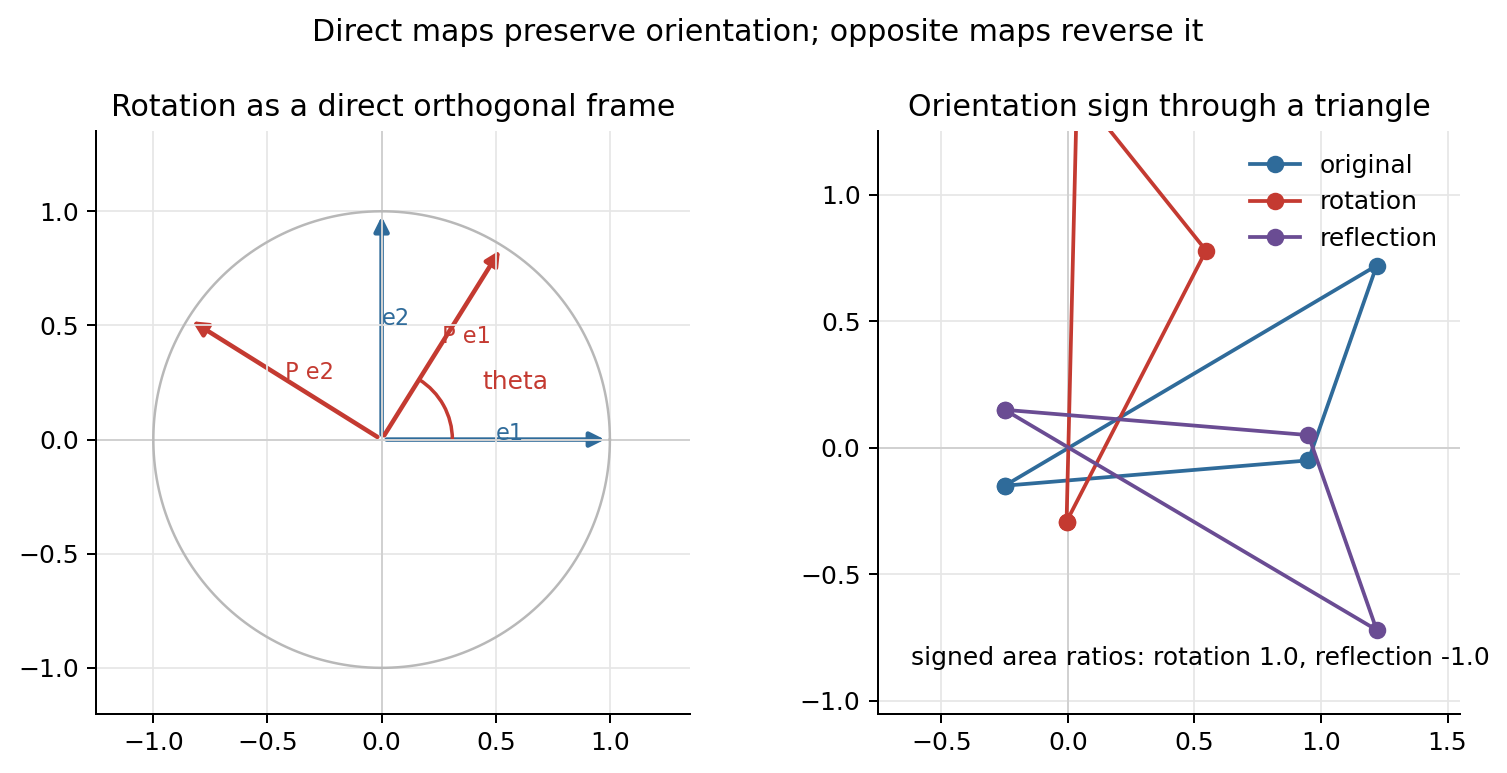

{'theta_degrees': 58.00000000000001,
 'orthogonal_residual': 2.379959194815893e-16,
 'rotation_determinant': 1.0000000000000002,
 'rotation_signed_area_ratio': 1.0,
 'reflection_signed_area_ratio': -1.0,
 'rotation_distance_error': 2.220446049250313e-16}

In [7]:
rot_theta = np.deg2rad(58)
P_rotation = rotation_matrix(rot_theta)
rotated_triangle = apply_affine(P_rotation, np.zeros(2), base_triangle)
reflected_triangle = apply_affine(np.diag([1.0, -1.0]), np.zeros(2), base_triangle)
unit_circle = np.column_stack([np.cos(np.linspace(0, 2*np.pi, 240)), np.sin(np.linspace(0, 2*np.pi, 240))])

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2))
ax = axes[0]
set_equal_axis(ax, (-1.25, 1.35), (-1.2, 1.35))
ax.plot(unit_circle[:, 0], unit_circle[:, 1], color="0.72", lw=1.0)
draw_vector(ax, [0, 0], [1, 0], color="#2F6B9A", label="e1")
draw_vector(ax, [0, 0], [0, 1], color="#2F6B9A", label="e2")
draw_vector(ax, [0, 0], P_rotation[:, 0], color="#C43A31", label="P e1")
draw_vector(ax, [0, 0], P_rotation[:, 1], color="#C43A31", label="P e2")
arc = Arc((0, 0), 0.62, 0.62, theta1=0, theta2=np.rad2deg(rot_theta), color="#C43A31", lw=1.4)
ax.add_patch(arc)
ax.text(0.44, 0.22, "theta", color="#C43A31")
ax.set_title("Rotation as a direct orthogonal frame")

ax = axes[1]
set_equal_axis(ax, (-0.75, 1.55), (-1.05, 1.25))
for tri, color, label in [
    (base_triangle, "#2F6B9A", "original"),
    (rotated_triangle, "#C43A31", "rotation"),
    (reflected_triangle, "#6A4C93", "reflection"),
]:
    closed_tri = np.r_[tri, tri[:1]]
    ax.plot(closed_tri[:, 0], closed_tri[:, 1], "o-", color=color, label=label)
area0 = signed_area2(base_triangle)
area_rot = signed_area2(rotated_triangle)
area_ref = signed_area2(reflected_triangle)
ax.text(-0.62, -0.86, f"signed area ratios: rotation {area_rot/area0:.1f}, reflection {area_ref/area0:.1f}")
ax.legend(loc="upper right", frameon=False)
ax.set_title("Orientation sign through a triangle")
fig.suptitle("Direct maps preserve orientation; opposite maps reverse it", y=1.03)

rotation_fig = save_figure(fig, "rotation-appendix-a1.png")
rotation_checks = {
    "theta_degrees": float(np.rad2deg(rot_theta)),
    "orthogonal_residual": orthogonal_residual(P_rotation),
    "rotation_determinant": float(np.linalg.det(P_rotation)),
    "rotation_signed_area_ratio": float(area_rot / area0),
    "reflection_signed_area_ratio": float(area_ref / area0),
    "rotation_distance_error": max_distance_error(base_triangle, rotated_triangle),
}
rotation_check_path = write_check("rotation-orientation-checks.json", rotation_checks)
assert rotation_checks["orthogonal_residual"] < 1e-12
assert abs(rotation_checks["rotation_determinant"] - 1) < 1e-12
assert abs(rotation_checks["rotation_signed_area_ratio"] - 1) < 1e-12
assert abs(rotation_checks["reflection_signed_area_ratio"] + 1) < 1e-12
display_artifact(rotation_fig, width=920)
rotation_checks


## 5. Composition: Matrices Multiply, Translations Are Carried Along

Composition has two pieces. The linear parts multiply in the usual order, and the second map also moves the first translation vector:

`G(F(v)) = QP v + Q a + b`.

This is why determinant signs multiply. In the plane, composing two reflections in lines through the origin gives a rotation through twice the angle between the lines. The left panel shows that route on one vector; the right panel is the orientation sign ledger.


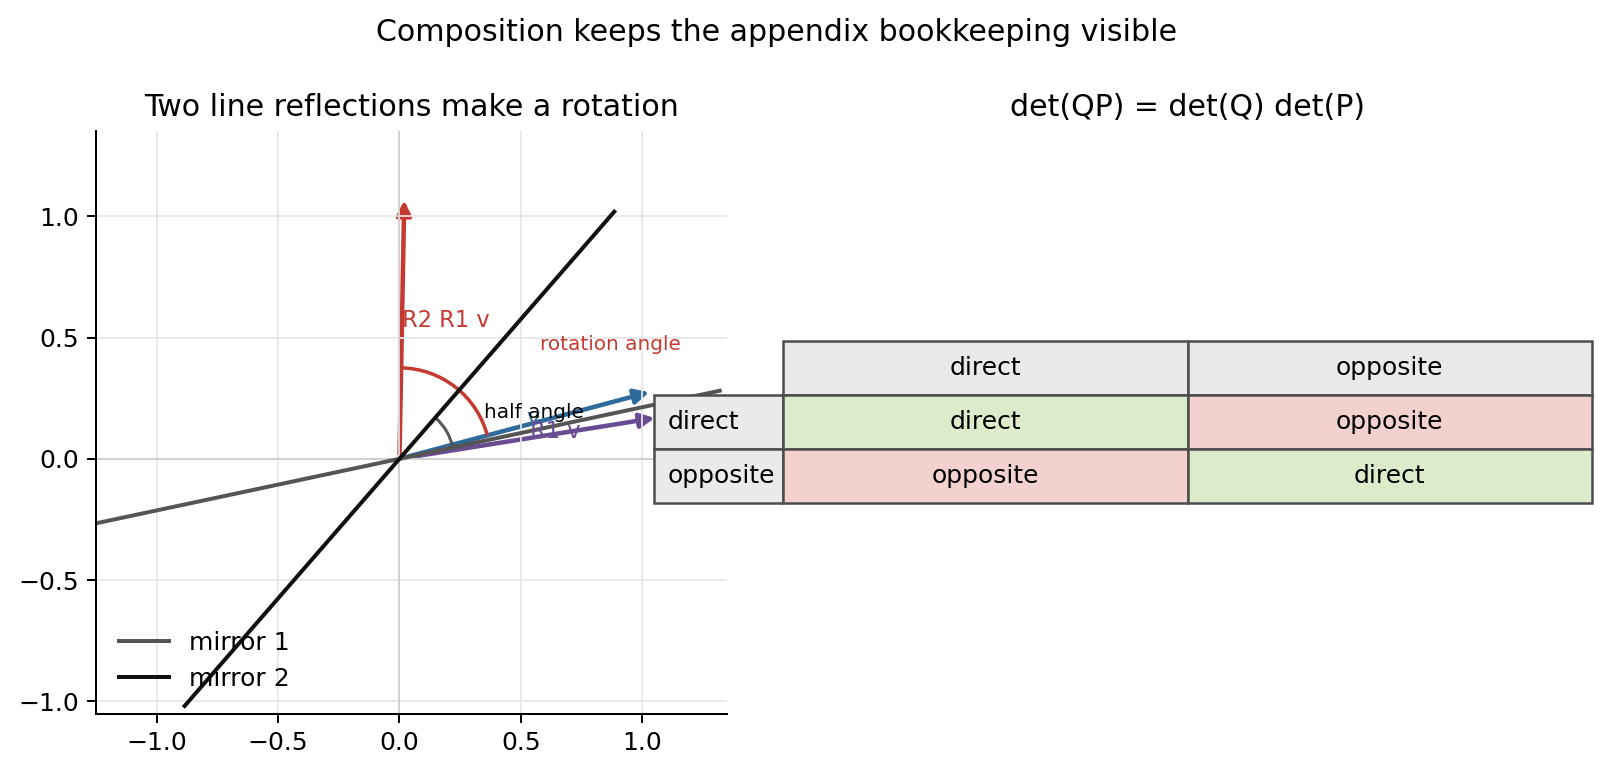

{'mirror_angle_degrees': 37.0,
 'rotation_angle_degrees': 74.0,
 'two_reflections_matrix_residual': 4.996003610813204e-16,
 'det_reflection_1': -1.0000000000000002,
 'det_reflection_2': -1.0,
 'det_composite': 1.0000000000000004,
 'affine_composition_formula_error': 2.482534153247273e-16,
 'composed_translation': [0.18217873713939875, 0.16783336695582002]}

In [8]:
phi1 = np.deg2rad(12)
angle_between = np.deg2rad(37)
phi2 = phi1 + angle_between
P_line1 = line_reflection_matrix(phi1)
P_line2 = line_reflection_matrix(phi2)
P_two_reflections = P_line2 @ P_line1
P_expected_rotation = rotation_matrix(2 * angle_between)
vector = np.array([1.05, 0.28])
vector_after_first = P_line1 @ vector
vector_after_second = P_line2 @ vector_after_first

F_P, F_a = rotation_matrix(np.deg2rad(24)), np.array([0.35, -0.18])
G_P, G_a = P_reflect, np.array([-0.12, 0.42])
composed_P = G_P @ F_P
composed_a = G_P @ F_a + G_a
composition_sample = apply_affine(G_P, G_a, apply_affine(F_P, F_a, base_points))
composition_formula_sample = apply_affine(composed_P, composed_a, base_points)
composition_formula_error = float(np.max(np.linalg.norm(composition_sample - composition_formula_sample, axis=1)))


def line_points(phi, radius=1.35):
    u = np.array([np.cos(phi), np.sin(phi)])
    return np.vstack([-radius * u, radius * u])


fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2))
ax = axes[0]
set_equal_axis(ax, (-1.25, 1.35), (-1.05, 1.35))
for phi, color, label in [(phi1, "#555555", "mirror 1"), (phi2, "#111111", "mirror 2")]:
    pts = line_points(phi)
    ax.plot(pts[:, 0], pts[:, 1], color=color, lw=1.6, label=label)
draw_vector(ax, [0, 0], vector, color="#2F6B9A", label="v")
draw_vector(ax, [0, 0], vector_after_first, color="#6A4C93", label="R1 v")
draw_vector(ax, [0, 0], vector_after_second, color="#C43A31", label="R2 R1 v")
arc1 = Arc((0, 0), 0.45, 0.45, theta1=np.rad2deg(phi1), theta2=np.rad2deg(phi2), color="#555555", lw=1.2)
arc2 = Arc(
    (0, 0),
    0.75,
    0.75,
    theta1=np.rad2deg(np.arctan2(vector[1], vector[0])),
    theta2=np.rad2deg(np.arctan2(vector_after_second[1], vector_after_second[0])),
    color="#C43A31",
    lw=1.4,
)
ax.add_patch(arc1)
ax.add_patch(arc2)
ax.text(0.35, 0.17, "half angle", fontsize=8)
ax.text(0.58, 0.45, "rotation angle", color="#C43A31", fontsize=8)
ax.legend(loc="lower left", frameon=False)
ax.set_title("Two line reflections make a rotation")

ax = axes[1]
ax.axis("off")
sign_table = [["direct", "opposite"], ["opposite", "direct"]]
row_labels = ["direct", "opposite"]
col_labels = ["direct", "opposite"]
table = ax.table(cellText=sign_table, rowLabels=row_labels, colLabels=col_labels, loc="center", cellLoc="center")
table.scale(1.25, 1.8)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("0.3")
    if row == 0 or col == -1:
        cell.set_facecolor("#EAEAEA")
    elif cell.get_text().get_text() == "direct":
        cell.set_facecolor("#DCECCB")
    else:
        cell.set_facecolor("#F2D1CE")
ax.set_title("det(QP) = det(Q) det(P)")
fig.suptitle("Composition keeps the appendix bookkeeping visible", y=1.03)

composition_fig = save_figure(fig, "composition-appendix-a1.png")
composition_checks = {
    "mirror_angle_degrees": float(np.rad2deg(angle_between)),
    "rotation_angle_degrees": float(np.rad2deg(2 * angle_between)),
    "two_reflections_matrix_residual": float(np.linalg.norm(P_two_reflections - P_expected_rotation, ord=np.inf)),
    "det_reflection_1": float(np.linalg.det(P_line1)),
    "det_reflection_2": float(np.linalg.det(P_line2)),
    "det_composite": float(np.linalg.det(P_two_reflections)),
    "affine_composition_formula_error": composition_formula_error,
    "composed_translation": composed_a.tolist(),
}
composition_check_path = write_check("composition-checks.json", composition_checks)
assert composition_checks["two_reflections_matrix_residual"] < 1e-12
assert abs(composition_checks["det_composite"] - 1) < 1e-12
assert composition_checks["affine_composition_formula_error"] < 1e-12
display_artifact(composition_fig, width=920)
composition_checks


## 6. Exact Matrix Identities

The numerical visuals are useful, but the appendix also works by exact matrix identities. SymPy lets us keep a compact symbolic scaffold beside the pictures: rotation matrices are orthogonal with determinant `1`; line reflections are orthogonal, square to the identity, and have determinant `-1`; two line reflections compose to a rotation by twice the angle between the lines.


In [9]:
t, p, q = sp.symbols("t p q", real=True)
R = sp.Matrix([[sp.cos(t), -sp.sin(t)], [sp.sin(t), sp.cos(t)]])
S_p = sp.Matrix([[sp.cos(2*p), sp.sin(2*p)], [sp.sin(2*p), -sp.cos(2*p)]])
S_q = sp.Matrix([[sp.cos(2*q), sp.sin(2*q)], [sp.sin(2*q), -sp.cos(2*q)]])
R_twice = sp.Matrix([[sp.cos(2*(q-p)), -sp.sin(2*(q-p))], [sp.sin(2*(q-p)), sp.cos(2*(q-p))]])

symbolic_checks = {
    "rotation_orthogonal": bool(sp.simplify(R.T * R - sp.eye(2)) == sp.zeros(2)),
    "rotation_det": str(sp.simplify(R.det())),
    "reflection_orthogonal": bool(sp.simplify(S_p.T * S_p - sp.eye(2)) == sp.zeros(2)),
    "reflection_square_identity": bool(sp.simplify(S_p * S_p - sp.eye(2)) == sp.zeros(2)),
    "reflection_det": str(sp.simplify(S_p.det())),
    "two_reflections_rotation": bool(sp.trigsimp(S_q * S_p - R_twice) == sp.zeros(2)),
}
symbolic_check_path = write_check("symbolic-orthogonal-identities.json", symbolic_checks)
assert symbolic_checks["rotation_orthogonal"]
assert symbolic_checks["rotation_det"] == "1"
assert symbolic_checks["reflection_orthogonal"]
assert symbolic_checks["reflection_square_identity"]
assert symbolic_checks["reflection_det"] == "-1"
assert symbolic_checks["two_reflections_rotation"]
symbolic_checks


{'rotation_orthogonal': True,
 'rotation_det': '1',
 'reflection_orthogonal': True,
 'reflection_square_identity': True,
 'reflection_det': '-1',
 'two_reflections_rotation': True}

## 7. `R^3`: Axis Rotation And Orientation Sign

In three dimensions, an orthogonal matrix has an invariant direction for the classifications used in the appendix. A direct isometry can rotate around an axis, while an opposite one reverses handedness. The Plotly scene lets you rotate the camera: the left frame is a rotation around the line spanned by `N`; the right frame is a reflection in the plane perpendicular to `N`.

The check beside the scene uses the cross-product identity for orthogonal matrices. Direct maps preserve the cross-product orientation; opposite maps insert a minus sign.


In [10]:
axis = np.array([1.0, 1.0, 1.35])
axis = axis / np.linalg.norm(axis)
P_axis_rotation = rodrigues(axis, np.deg2rad(67))
P_plane_reflection = reflection_matrix_from_normal(axis)

basis3 = np.eye(3)
rot_basis = P_axis_rotation @ basis3
ref_basis = P_plane_reflection @ basis3

v3 = np.array([0.72, -0.35, 0.58])
w3 = np.array([-0.18, 0.88, 0.21])


def cross_identity_residual(P):
    left = np.cross(P @ v3, P @ w3)
    right = np.linalg.det(P) * (P @ np.cross(v3, w3))
    return float(np.linalg.norm(left - right))


r3_checks = {
    "axis": axis.tolist(),
    "axis_rotation_det": float(np.linalg.det(P_axis_rotation)),
    "axis_rotation_orthogonal_residual": orthogonal_residual(P_axis_rotation),
    "plane_reflection_det": float(np.linalg.det(P_plane_reflection)),
    "plane_reflection_orthogonal_residual": orthogonal_residual(P_plane_reflection),
    "axis_rotation_cross_product_residual": cross_identity_residual(P_axis_rotation),
    "plane_reflection_cross_product_residual": cross_identity_residual(P_plane_reflection),
    "axis_fixed_residual": float(np.linalg.norm(P_axis_rotation @ axis - axis)),
    "reflection_normal_flipped_residual": float(np.linalg.norm(P_plane_reflection @ axis + axis)),
}
r3_check_path = write_check("orientation-cross-product-checks.json", r3_checks)
assert r3_checks["axis_rotation_orthogonal_residual"] < 1e-12
assert r3_checks["plane_reflection_orthogonal_residual"] < 1e-12
assert abs(r3_checks["axis_rotation_det"] - 1) < 1e-12
assert abs(r3_checks["plane_reflection_det"] + 1) < 1e-12
assert r3_checks["axis_rotation_cross_product_residual"] < 1e-12
assert r3_checks["plane_reflection_cross_product_residual"] < 1e-12

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("Direct: rotation about an axis", "Opposite: reflection across a plane"),
)

colors = ["#C43A31", "#2F6B9A", "#5C8A4A"]
labels = ["e1", "e2", "e3"]


def add_segment(fig, col, start, end, name, color, width=6, dash=None, showlegend=False):
    fig.add_trace(
        go.Scatter3d(
            x=[start[0], end[0]], y=[start[1], end[1]], z=[start[2], end[2]],
            mode="lines+markers",
            line=dict(color=color, width=width, dash=dash),
            marker=dict(size=3, color=color),
            name=name,
            showlegend=showlegend,
        ),
        row=1,
        col=col,
    )


axis_line = np.vstack([-1.25 * axis, 1.25 * axis])
for col in [1, 2]:
    add_segment(fig, col, axis_line[0], axis_line[1], "axis N", "#111111", width=5, dash="dash", showlegend=(col == 1))
    for i, (color, label) in enumerate(zip(colors, labels)):
        add_segment(fig, col, np.zeros(3), basis3[:, i], label, "#999999", width=3, showlegend=False)

for i, (color, label) in enumerate(zip(colors, labels)):
    add_segment(fig, 1, np.zeros(3), rot_basis[:, i], "rotated " + label, color, width=7, showlegend=True)
    add_segment(fig, 2, np.zeros(3), ref_basis[:, i], "reflected " + label, color, width=7, showlegend=False)

u = np.array([axis[1], -axis[0], 0.0])
if np.linalg.norm(u) < 1e-8:
    u = np.array([1.0, 0.0, 0.0])
u = u / np.linalg.norm(u)
w = np.cross(axis, u)
angles = np.linspace(0, 2*np.pi, 50)
plane_circle = np.array([0.85*np.cos(a)*u + 0.85*np.sin(a)*w for a in angles])
fig.add_trace(
    go.Mesh3d(
        x=plane_circle[:, 0], y=plane_circle[:, 1], z=plane_circle[:, 2],
        color="#D7E3ED", opacity=0.35, name="reflection plane", showlegend=True,
    ),
    row=1,
    col=2,
)

for scene_name in ["scene", "scene2"]:
    fig.update_layout(**{scene_name: dict(aspectmode="cube", xaxis_title="x", yaxis_title="y", zaxis_title="z")})
fig.update_layout(height=520, width=980, margin=dict(l=0, r=0, t=50, b=0), legend=dict(orientation="h", y=-0.04))

r3_html = INTERACTIVE_DIR / "r3-orientation-cross-product.html"
fig.write_html(str(r3_html), include_plotlyjs="cdn", full_html=True)
assert_artifact(r3_html, min_bytes=2000)
display_artifact(r3_html, width="100%", height=540)
r3_checks


{'axis': [0.5114771692875645, 0.5114771692875645, 0.690494178538212],
 'axis_rotation_det': 1.0,
 'axis_rotation_orthogonal_residual': 2.7545768253600634e-16,
 'plane_reflection_det': -1.0,
 'plane_reflection_orthogonal_residual': 6.121056695382023e-17,
 'axis_rotation_cross_product_residual': 1.1443916996305594e-16,
 'plane_reflection_cross_product_residual': 1.2412670766236366e-16,
 'axis_fixed_residual': 0.0,
 'reflection_normal_flipped_residual': 0.0}

## Applied Lab: Classify An Affine Isometry From Data

The lab treats an isometry as data: a matrix `P`, a vector `a`, and a sample constellation. The classifier below does not try to prove the full theorem. It asks the computational questions a reader should learn to ask:

- Is `P` orthogonal?
- Is the determinant sign direct or opposite?
- Are distances preserved on sample points?
- Does the affine map have fixed points, and if so what is their dimension?
- Does the inverse formula recover the original points?

The rows include pure translations, rotations with shifted centers, hyperplane reflections, and an opposite composition with no fixed point in the plane.


In [11]:
def fixed_set_summary(P, a, tol=1e-9):
    P = np.asarray(P, dtype=float)
    a = np.asarray(a, dtype=float)
    A = np.eye(P.shape[0]) - P
    sol, *_ = np.linalg.lstsq(A, a, rcond=None)
    residual = float(np.linalg.norm(A @ sol - a))
    rank = int(np.linalg.matrix_rank(A, tol=tol))
    if residual > 1e-8:
        return "none", 0, residual, sol
    dimension = P.shape[0] - rank
    if dimension == 0:
        label = "one point"
    elif dimension == 1:
        label = "line"
    elif dimension == 2:
        label = "plane"
    else:
        label = f"dimension {dimension}"
    return label, int(dimension), residual, sol


def affine_inverse_residual(P, a, points):
    image = apply_affine(P, a, points)
    recovered = apply_affine(P.T, -P.T @ a, image)
    return float(np.max(np.linalg.norm(recovered - points, axis=1)))


lab_cases = []
lab_cases.append(("translation", np.eye(2), np.array([0.55, -0.22]), "direct translation; no fixed point unless a=0"))
lab_cases.append(("rotation plus translation", rotation_matrix(np.deg2rad(52)), np.array([0.42, 0.18]), "direct planar motion with a shifted rotation center"))
lab_cases.append(("line reflection", P_reflect, a_reflect, "opposite motion; fixed set is the mirror line"))
lab_cases.append(("reflection plus parallel translation", np.diag([1.0, -1.0]), np.array([0.48, 0.0]), "opposite planar motion with no fixed point"))
lab_cases.append(("R3 axis rotation", P_axis_rotation, np.zeros(3), "direct spatial rotation fixing an axis"))
lab_cases.append(("R3 plane reflection", P_plane_reflection, np.zeros(3), "opposite spatial reflection fixing a plane"))

sample2 = np.array([[-0.3, -0.2], [0.9, -0.1], [0.4, 0.8], [1.1, 0.6]])
sample3 = np.array([[-0.2, 0.1, 0.4], [0.7, -0.3, 0.2], [0.2, 0.9, -0.1], [0.5, 0.4, 0.8]])
rows = []
for name, P, a, note in lab_cases:
    points = sample3 if P.shape[0] == 3 else sample2
    image = apply_affine(P, a, points)
    det = float(np.linalg.det(P))
    fixed_label, fixed_dimension, fixed_residual, fixed_sample = fixed_set_summary(P, a)
    rows.append({
        "case": name,
        "dimension": int(P.shape[0]),
        "determinant": det,
        "orientation": "direct" if det > 0 else "opposite",
        "orthogonal_residual": orthogonal_residual(P),
        "max_distance_error": max_distance_error(points, image),
        "inverse_residual": affine_inverse_residual(P, a, points),
        "fixed_set": fixed_label,
        "fixed_set_dimension": fixed_dimension,
        "fixed_set_residual": fixed_residual,
        "translation_norm": float(np.linalg.norm(a)),
        "note": note,
    })

lab_table = pd.DataFrame(rows)
lab_csv = TABLE_DIR / "applied-lab-isometry-classifier.csv"
lab_table.to_csv(lab_csv, index=False)
lab_checks = {
    "row_count": int(len(lab_table)),
    "max_orthogonal_residual": float(lab_table["orthogonal_residual"].max()),
    "max_distance_error": float(lab_table["max_distance_error"].max()),
    "max_inverse_residual": float(lab_table["inverse_residual"].max()),
    "direct_count": int((lab_table["orientation"] == "direct").sum()),
    "opposite_count": int((lab_table["orientation"] == "opposite").sum()),
    "cases": lab_table["case"].tolist(),
}
lab_check_path = write_check("applied-lab-isometry-classifier.json", lab_checks)
assert_artifact(lab_csv, min_bytes=256)
assert lab_checks["max_orthogonal_residual"] < 1e-12
assert lab_checks["max_distance_error"] < 1e-12
assert lab_checks["max_inverse_residual"] < 1e-12
lab_table


,case,dimension,determinant,orientation,orthogonal_residual,max_distance_error,inverse_residual,fixed_set,fixed_set_dimension,fixed_set_residual,translation_norm,note
0,translation,2,1.0,direct,0.000000e+00,2.220446e-16,1.110223e-16,none,0,5.923681e-01,0.592368,direct translation; no fixed point unless a=0
1,rotation plus translation,2,1.0,direct,1.094454e-17,2.220446e-16,2.371437e-16,one point,0,5.551115e-17,0.456946,direct planar motion with a shifted rotation c...
2,line reflection,2,-1.0,opposite,3.161147e-16,4.440892e-16,4.002966e-16,line,1,2.775558e-16,0.640000,opposite motion; fixed set is the mirror line
3,reflection plus parallel translation,2,-1.0,opposite,0.000000e+00,1.110223e-16,1.110223e-16,none,0,4.800000e-01,0.480000,opposite planar motion with no fixed point
4,R3 axis rotation,3,1.0,direct,2.754577e-16,2.220446e-16,1.422050e-16,line,1,0.000000e+00,0.000000,direct spatial rotation fixing an axis
5,R3 plane reflection,3,-1.0,opposite,6.121057e-17,1.110223e-16,2.220446e-16,plane,2,0.000000e+00,0.000000,opposite spatial reflection fixing a plane


## Final Sanity

The last check is deliberately redundant. It verifies the same ideas at three levels: mathematical identities, generated artifacts, and notebook hygiene. If a future edit changes a matrix formula, moves an artifact, or reintroduces the generic visual builder, this cell should fail loudly.


In [12]:
artifact_paths = [
    isometry_fig,
    translation_fig,
    reflection_fig,
    rotation_fig,
    composition_fig,
    r3_html,
    source_path,
    storyboard_path,
    isometry_check_path,
    translation_check_path,
    reflection_check_path,
    rotation_check_path,
    composition_check_path,
    symbolic_check_path,
    r3_check_path,
    lab_csv,
    lab_check_path,
]

for path in artifact_paths:
    min_bytes = 64 if path.suffix.lower() in {".json", ".csv"} else 1000
    assert_artifact(path, min_bytes=min_bytes)

metric_residuals = [
    isometry_checks["max_pairwise_distance_error"],
    translation_checks["max_pairwise_distance_error"],
    reflection_checks["max_pairwise_distance_error"],
    rotation_checks["rotation_distance_error"],
    composition_checks["affine_composition_formula_error"],
    lab_checks["max_distance_error"],
]
orthogonal_residuals = [
    isometry_checks["orthogonal_residual"],
    reflection_checks["orthogonal_residual"],
    rotation_checks["orthogonal_residual"],
    r3_checks["axis_rotation_orthogonal_residual"],
    r3_checks["plane_reflection_orthogonal_residual"],
    lab_checks["max_orthogonal_residual"],
]
orientation_residuals = [
    abs(rotation_checks["rotation_signed_area_ratio"] - 1),
    abs(rotation_checks["reflection_signed_area_ratio"] + 1),
    composition_checks["two_reflections_matrix_residual"],
    r3_checks["axis_rotation_cross_product_residual"],
    r3_checks["plane_reflection_cross_product_residual"],
]

forbidden_builder = "build_" + "unit_" + "visuals"
notebook_text = NOTEBOOK_PATH.read_text(encoding="utf-8")
notebook_cell_count = len(json.loads(notebook_text)["cells"])

final_sanity = {
    "unit": UNIT,
    "source_span": source_span,
    "artifact_count": len(artifact_paths),
    "artifact_files": [str(path.relative_to(UNIT_ARTIFACT_ROOT)).replace("\\", "/") for path in artifact_paths if path.is_relative_to(UNIT_ARTIFACT_ROOT)],
    "max_metric_residual": float(max(metric_residuals)),
    "max_orthogonal_residual": float(max(orthogonal_residuals)),
    "max_orientation_residual": float(max(orientation_residuals)),
    "reflection_self_inverse_residual": reflection_checks["self_inverse_residual"],
    "composition_formula_error": composition_checks["affine_composition_formula_error"],
    "symbolic_checks_all_passed": all(value is True or value in {"1", "-1"} for value in symbolic_checks.values()),
    "applied_lab_rows": lab_checks["row_count"],
    "direct_cases": lab_checks["direct_count"],
    "opposite_cases": lab_checks["opposite_count"],
    "notebook_has_no_generic_visual_builder": forbidden_builder not in notebook_text,
}

assert final_sanity["max_metric_residual"] < 1e-10
assert final_sanity["max_orthogonal_residual"] < 1e-10
assert final_sanity["max_orientation_residual"] < 1e-10
assert final_sanity["reflection_self_inverse_residual"] < 1e-10
assert final_sanity["symbolic_checks_all_passed"]
assert final_sanity["applied_lab_rows"] >= 6
assert final_sanity["direct_cases"] >= 3 and final_sanity["opposite_cases"] >= 3
assert final_sanity["notebook_has_no_generic_visual_builder"]

final_sanity_path = write_check("final-sanity.json", final_sanity)
notebook_sanity_path = write_check("notebook-sanity.json", {
    "unit": UNIT,
    "notebook": str(NOTEBOOK_PATH.relative_to(BOOK_ROOT)).replace("\\", "/"),
    "cell_count": notebook_cell_count,
    "has_source_span": True,
    "has_translation_guide": True,
    "has_route": True,
    "has_applied_lab": True,
    "has_final_sanity": True,
    "no_generic_visual_builder": final_sanity["notebook_has_no_generic_visual_builder"],
})
assert_artifact(final_sanity_path, min_bytes=512)
assert_artifact(notebook_sanity_path, min_bytes=256)
final_sanity


{'unit': 'appendix-a1',
 'source_span': {'book': 'Andrew Pressley, Elementary Differential Geometry, Second Edition',
  'unit': 'appendix-a1',
  'title': 'Isometries of Euclidean spaces',
  'pdf_pages': '382-389',
  'printed_label': 'Appendix 1',
  'source_use': 'orientation only; no prose, figures, exercises, screenshots, or page crops copied'},
 'artifact_count': 17,
 'artifact_files': ['figures/isometry-appendix-a1.png',
  'figures/translation-appendix-a1.png',
  'figures/reflection-appendix-a1.png',
  'figures/rotation-appendix-a1.png',
  'figures/composition-appendix-a1.png',
  'interactive/r3-orientation-cross-product.html',
  'checks/source-span.json',
  'checks/visual-storyboard.json',
  'checks/orthogonal-affine-checks.json',
  'checks/translation-checks.json',
  'checks/reflection-checks.json',
  'checks/rotation-orientation-checks.json',
  'checks/composition-checks.json',
  'checks/symbolic-orthogonal-identities.json',
  'checks/orientation-cross-product-checks.json',
  'ta

## Takeaways

- Euclidean isometries become computationally transparent once written as `F(v)=Pv+a` with `P` orthogonal.
- Translation changes location but not the frame. The orthogonal matrix changes the frame but keeps dot products and distances intact.
- Reflections are opposite isometries: they are self-inverse, fix a hyperplane, and reverse orientation.
- Rotations are direct isometries. In the plane, two reflections in intersecting lines compose to a rotation through twice the angle between the lines.
- Composition is controlled by `QP` and `Qa+b`; determinant signs multiply exactly the way orientation behavior does.
- In `R^3`, the determinant sign also controls cross products, so direct maps preserve handedness and opposite maps reverse it.
